# GTSRB - German Traffic Sign Recognition Benchmark

**Dataset:** https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/data

In [ ]:
# Install kagglehub if not already installed
!pip install kagglehub


In [25]:
import kagglehub
import os
import shutil

# Target directory (next to this notebook)
target_dir = os.path.join(os.getcwd(), "dataset")

# Download the dataset from Kaggle
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Kaggle downloaded to: {path}")

# Copy to project directory if not already there
if os.path.abspath(path) != os.path.abspath(target_dir):
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    shutil.copytree(path, target_dir)
    path = target_dir

print(f"Dataset available at: {path}")
print(f"Contents: {os.listdir(path)}")


Kaggle downloaded to: /home/krstff/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Dataset available at: /home/krstff/gtsrb/dataset
Contents: ['Test', 'Test.csv', 'train', 'Meta.csv', 'Meta', 'meta', 'Train', 'test', 'Train.csv']


In [26]:
# List the contents of the downloaded dataset
!ls -la {path}


total 3340
drwxrwxr-x  8 krstff krstff    4096 Jul  9 16:52 .
drwxrwxr-x  5 krstff krstff    4096 Jul  9 16:59 ..
drwxrwxr-x  2 krstff krstff    4096 Jul  9 16:52 meta
drwxrwxr-x  2 krstff krstff    4096 Jul  9 16:52 Meta
-rw-rw-r--  1 krstff krstff    1033 Jul  9 16:52 Meta.csv
drwxrwxr-x  2 krstff krstff  507904 Jul  9 16:52 test
drwxrwxr-x  2 krstff krstff  507904 Jul  9 16:52 Test
-rw-rw-r--  1 krstff krstff  427897 Jul  9 16:52 Test.csv
drwxrwxr-x 45 krstff krstff    4096 Jul  9 16:53 train
drwxrwxr-x 45 krstff krstff    4096 Jul  9 16:52 Train
-rw-rw-r--  1 krstff krstff 1940896 Jul  9 16:52 Train.csv


## Basic Data Exploration

In [27]:
import os

# List the dataset folder structure
for item in sorted(os.listdir(path)):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  📁 {item}/  ({count} items)")
    else:
        print(f"  📄 {item}")


  📁 Meta/  (45 items)
  📄 Meta.csv
  📁 Test/  (12631 items)
  📄 Test.csv
  📁 Train/  (43 items)
  📄 Train.csv
  📁 meta/  (45 items)
  📁 test/  (12631 items)
  📁 train/  (43 items)


In [28]:
import pandas as pd

# Load the training labels CSV (lives at dataset root)
df = pd.read_csv(os.path.join(path, "Train.csv"))
print(f"Training samples: {len(df)}")
print()
df.head(10)


Training samples: 39209



,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
5,31,27,6,5,26,22,20,Train/20/00020_00000_00005.png
6,31,28,6,6,26,23,20,Train/20/00020_00000_00006.png
7,31,28,6,6,26,23,20,Train/20/00020_00000_00007.png
8,31,29,5,6,26,24,20,Train/20/00020_00000_00008.png
9,34,32,6,6,29,26,20,Train/20/00020_00000_00009.png


In [29]:
# Class distribution
print(f"Number of classes: {df['ClassId'].nunique()}")
print()
counts = df['ClassId'].value_counts().sort_index()
counts


Number of classes: 43



ClassId
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64

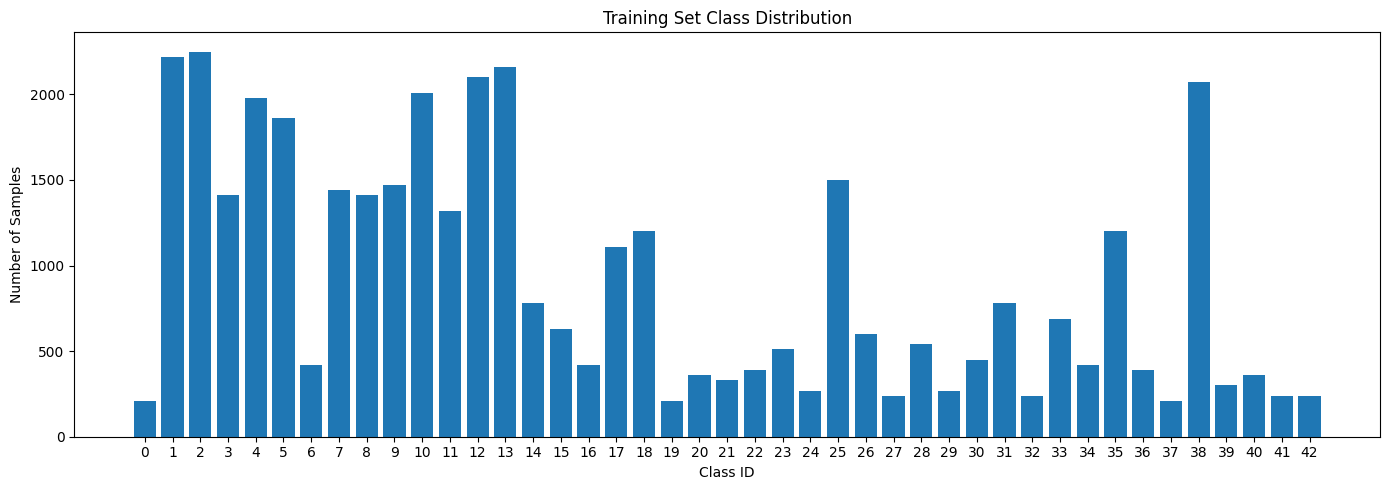

In [30]:
import matplotlib.pyplot as plt

# Plot class distribution
counts = df['ClassId'].value_counts().sort_index()
plt.figure(figsize=(14, 5))
plt.bar(counts.index, counts.values)
plt.xlabel("Class ID")
plt.ylabel("Number of Samples")
plt.title("Training Set Class Distribution")
plt.xticks(range(0, 43))
plt.tight_layout()
plt.show()


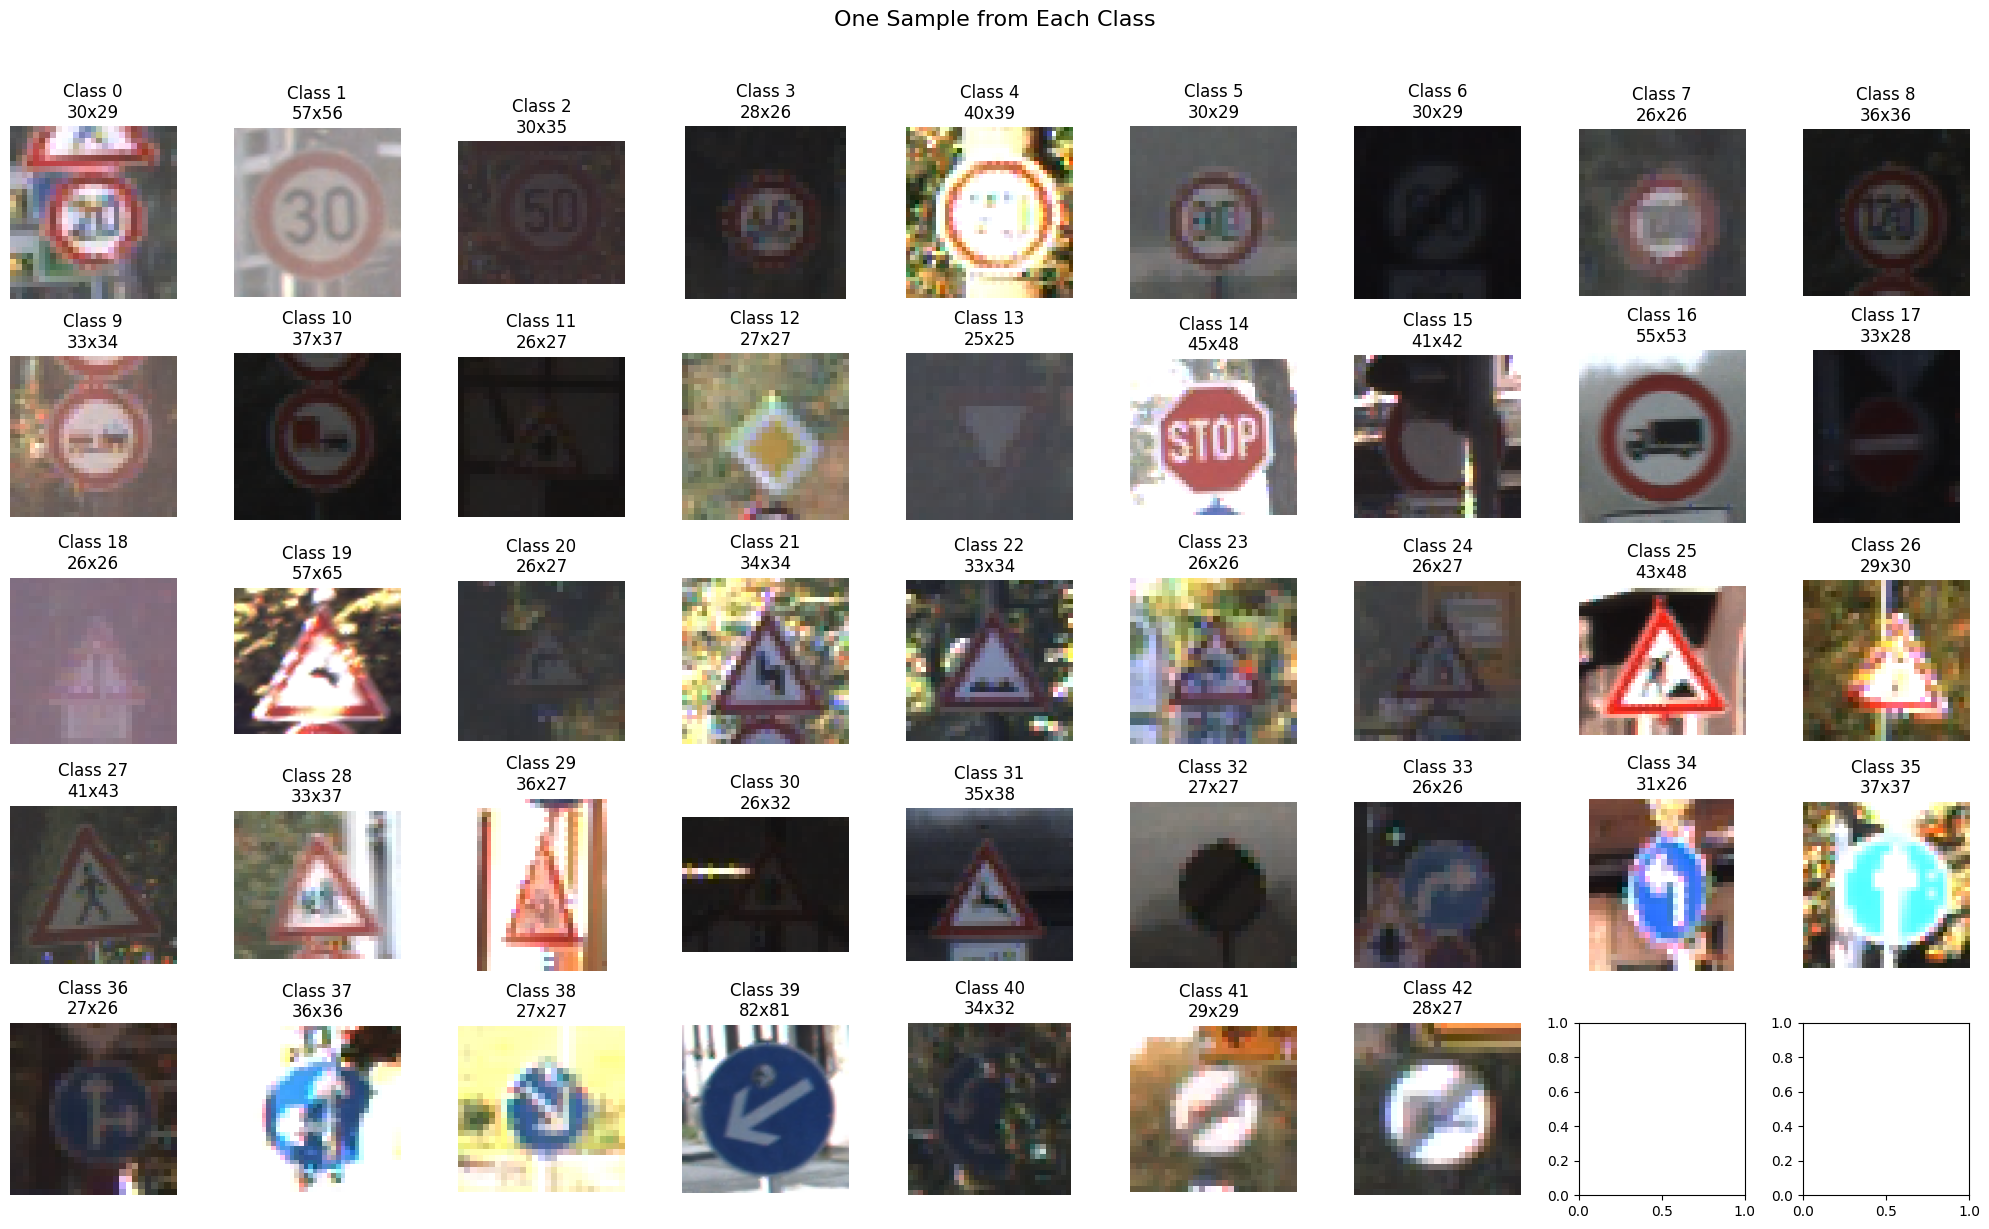

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

# Display sample images from each class
fig, axes = plt.subplots(5, 9, figsize=(20, 12))
axes = axes.flatten()

for cls in sorted(df['ClassId'].unique()):
    sample = df[df["ClassId"] == cls].iloc[0]
    # Path column already contains relative path from dataset root
    img_path = os.path.join(path, sample['Path'])
    img = Image.open(img_path)
    axes[cls].imshow(img)
    axes[cls].set_title(f"Class {cls}\n{img.size[1]}x{img.size[0]}")
    axes[cls].axis("off")

plt.suptitle("One Sample from Each Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [32]:
# Image size statistics
heights = df['Height'].value_counts().sort_index()
widths = df['Width'].value_counts().sort_index()

print("Image heights:")
print(heights)
print()
print("Image widths:")
print(widths)


Image heights:
Height
25       70
26      287
27      572
28      850
29     1111
       ... 
205       1
211       1
213       2
219       1
225       1
Name: count, Length: 176, dtype: int64

Image widths:
Width
25       54
26      341
27      711
28      910
29     1105
       ... 
226       1
229       1
230       1
231       1
243       1
Name: count, Length: 187, dtype: int64


In [33]:
# Check test set
test_dir = os.path.join(path, "Test")
test_images = os.listdir(test_dir)
print(f"Test images: {len(test_images)}")

# Load test labels
df_test = pd.read_csv(os.path.join(path, "Test.csv"))
print(f"Test labels: {len(df_test)}")
print()
df_test.head()


Test images: 12631
Test labels: 12630



,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png
